In [38]:
print(1)


1


In [39]:
import torch
print(torch.__version__)

2.8.0+cu129


In [40]:
import sys
print("Python utilisé :", sys.executable)
print("Version Python :", sys.version)

Python utilisé : /opt/pytorch/bin/python
Version Python : 3.12.10 (main, Nov 15 2025, 00:24:01) [GCC 11.5.0 20240719 (Red Hat 11.5.0-5)]


In [41]:
import torch
print("Torch version :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

Torch version : 2.8.0+cu129
CUDA disponible : True


In [42]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
#os.chdir(r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project")
#os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [43]:
import seaborn as sns

In [44]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cuda:0


In [45]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load_Forecasts", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN_DAM_Forecasts", "FR_ren_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test

def create_sliding_window(data_df,string, window_days=7, forecast_horizon=24):
    """
    Create sliding windows for day-ahead electricity price forecasting.
    Each input corresponds to `window_days` past days (window_days * 24 hours),
    and each output corresponds to the next day's 24 hourly prices.

    Parameters
    ----------
    data_df : pd.DataFrame
        Must contain a 'EUR/MWh' column with hourly prices.
    window_days : int
        Number of past days (each 24 hours) used as input.
    forecast_horizon : int
        Typically 24 (hours in the day to forecast).
    string :  the name of the column of interest
    Returns
    -------
    X : np.ndarray of shape (n_samples, window_days*24)
    y : np.ndarray of shape (n_samples, forecast_horizon)
    """
    series = data_df[string].values
    hours_per_day = 24
    window_size = window_days * hours_per_day

    X, y, y_day_before, y_week_before = [], [], [], []

    for i in range(0, len(series) - window_size - forecast_horizon + 1):
        # Input window: past `window_size` hours
        X_window = series[i : i + window_size]
        # Target: next `forecast_horizon` hours
        y_target = series[i + window_size : i + window_size + forecast_horizon]

        # --- Naive baselines ---
        # previous day
        if i - hours_per_day >= 0:
            y_prev_day = series[i + window_size - hours_per_day : i + window_size - hours_per_day + forecast_horizon]
        else:
            y_prev_day = np.full(forecast_horizon, np.nan)

        # previous week
        if i - 7 * hours_per_day >= 0:
            y_prev_week = series[i + window_size - 7 * hours_per_day : i + window_size - 7 * hours_per_day + forecast_horizon]
        else:
            y_prev_week = np.full(forecast_horizon, np.nan)

        X.append(X_window)
        y.append(y_target)
        y_day_before.append(y_prev_day)
        y_week_before.append(y_prev_week)

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), np.asarray(y_day_before, dtype=np.float32), np.asarray(y_week_before, dtype=np.float32)

In [46]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data=pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'],how='inner')
all_data=pd.merge(all_data, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'],how='inner')
all_data


,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,MW,Wind Onshore,Solar
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00
...,...,...,...,...,...,...,...,...,...,...
52182,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72
52183,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89
52184,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00
52185,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00


In [47]:

#Normalization and splitting
train_df_FR, dev_df_FR, test_df_FR = split_data(all_data)

mean_FR = train_df_FR['EUR/MWh'].mean()
std_FR = train_df_FR['EUR/MWh'].std()
train_df_FR['EUR/MWh'] = (train_df_FR['EUR/MWh'] - mean_FR) / std_FR
dev_df_FR['EUR/MWh'] = (dev_df_FR['EUR/MWh'] - mean_FR) / std_FR
test_df_FR['EUR/MWh'] = (test_df_FR['EUR/MWh'] - mean_FR) / std_FR
mean_load_FR = train_df_FR['MW'].mean()
std_load_FR = train_df_FR['MW'].std()
train_df_FR['MW'] = (train_df_FR['MW'] - mean_load_FR) / std_load_FR
dev_df_FR['MW'] = (dev_df_FR['MW'] - mean_load_FR) / std_load_FR
test_df_FR['MW'] = (test_df_FR['MW'] - mean_load_FR) / std_load_FR
mean_solar_FR = train_df_FR['Solar'].mean()
std_solar_FR = train_df_FR['Solar'].std()
train_df_FR['Solar'] = (train_df_FR['Solar'] - mean_solar_FR) / std_solar_FR
dev_df_FR['Solar'] = (dev_df_FR['Solar'] - mean_solar_FR) / std_solar_FR
test_df_FR['Solar'] = (test_df_FR['Solar'] - mean_solar_FR) / std_solar_FR
mean_wind_FR = train_df_FR['Wind Onshore'].mean()
std_wind_FR = train_df_FR['Wind Onshore'].std()
train_df_FR['Wind Onshore'] = (train_df_FR['Wind Onshore'] - mean_wind_FR) / std_wind_FR
dev_df_FR['Wind Onshore'] = (dev_df_FR['Wind Onshore'] - mean_wind_FR) / std_wind_FR
test_df_FR['Wind Onshore'] = (test_df_FR['Wind Onshore'] - mean_wind_FR) / std_wind_FR

#Create a dictonary for storing means and standard deviations
normalization_params_FR = {
    'EUR/MWh': {'mean': mean_FR, 'std': std_FR},
    'MW': {'mean': mean_load_FR, 'std': std_load_FR},
    'Solar': {'mean': mean_solar_FR, 'std': std_solar_FR},
    'Wind Onshore': {'mean': mean_wind_FR, 'std': std_wind_FR}
}

In [48]:
#Create sliding windows

window_days = 7
forecast_horizon = 24
X_train_FR, y_train_FR, y_train_FR_1d, y_train_FR_7d = create_sliding_window(train_df_FR, string='EUR/MWh', window_days=7, forecast_horizon=24)
X_dev_FR,   y_dev_FR,   y_dev_FR_1d, y_dev_FR_7d = create_sliding_window(dev_df_FR, string='EUR/MWh', window_days=7, forecast_horizon=24)
X_test_FR,  y_test_FR,  y_test_FR_1d, y_test_FR_7d = create_sliding_window(test_df_FR, string='EUR/MWh', window_days=7, forecast_horizon=24)
X_load_train_FR, _, _, _ = create_sliding_window(train_df_FR, string='MW', window_days=7, forecast_horizon=24)
X_load_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR, string='MW', window_days=7, forecast_horizon=24)
X_load_test_FR,  _, _, _ = create_sliding_window(test_df_FR, string='MW', window_days=7, forecast_horizon=24)
X_solar_train_FR, _, _, _ = create_sliding_window(train_df_FR, string='Solar', window_days=7, forecast_horizon=24)
X_solar_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR, string='Solar', window_days=7, forecast_horizon=24)
X_solar_test_FR,  _, _, _ = create_sliding_window(test_df_FR, string='Solar', window_days=7, forecast_horizon=24)
X_wind_train_FR, _, _, _ = create_sliding_window(train_df_FR, string='Wind Onshore', window_days=7, forecast_horizon=24)
X_wind_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR, string='Wind Onshore', window_days=7, forecast_horizon=24)
X_wind_test_FR,  _, _, _ = create_sliding_window(test_df_FR, string='Wind Onshore', window_days=7, forecast_horizon=24)


In [49]:
print(y_test_FR_1d.shape)
y_test_FR_1d


(8566, 24)


array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [-0.5172468 , -0.44930553, -0.52386755, ..., -0.32808313,
        -0.20094937,  0.05229351],
       [-0.44930553, -0.52386755, -0.5913359 , ..., -0.20094937,
         0.05229351, -0.2925361 ],
       [-0.52386755, -0.5913359 , -0.622075  , ...,  0.05229351,
        -0.2925361 , -0.32902893]], dtype=float32)

In [13]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df
train_df_FR_cyclic = add_cyclical_features(train_df_FR)
dev_df_FR_cyclic = add_cyclical_features(dev_df_FR)
test_df_FR_cyclic = add_cyclical_features(test_df_FR)
X_sin_hour_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['sin_hour']], string='sin_hour', window_days=7, forecast_horizon=24)
X_cos_hour_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['cos_hour']], string='cos_hour', window_days=7, forecast_horizon=24)
X_sin_hour_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['sin_hour']], string='sin_hour', window_days=7, forecast_horizon=24)
X_cos_hour_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['cos_hour']], string='cos_hour', window_days=7, forecast_horizon=24)
X_sin_hour_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['sin_hour']], string='sin_hour', window_days=7, forecast_horizon=24)
X_cos_hour_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['cos_hour']], string='cos_hour', window_days=7, forecast_horizon=24)
X_sin_day_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['sin_day']], string='sin_day', window_days=7, forecast_horizon=24)
X_cos_day_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['cos_day']], string='cos_day', window_days=7, forecast_horizon=24)
X_sin_day_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['sin_day']], string='sin_day', window_days=7, forecast_horizon=24)
X_cos_day_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['cos_day']], string='cos_day', window_days=7, forecast_horizon=24)
X_sin_day_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['sin_day']], string='sin_day', window_days=7, forecast_horizon=24)
X_cos_day_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['cos_day']], string='cos_day', window_days=7, forecast_horizon=24)
X_sin_month_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['sin_month']], string='sin_month', window_days=7, forecast_horizon=24)
X_cos_month_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['cos_month']], string='cos_month', window_days=7, forecast_horizon=24)
X_sin_month_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['sin_month']], string='sin_month', window_days=7, forecast_horizon=24)
X_cos_month_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['cos_month']], string='cos_month', window_days=7, forecast_horizon=24)
X_sin_month_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['sin_month']], string='sin_month', window_days=7, forecast_horizon=24)
X_cos_month_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['cos_month']], string='cos_month', window_days=7, forecast_horizon=24)

In [14]:
print(X_train_FR.shape)
print(X_load_train_FR.shape)
print(X_solar_train_FR.shape)
print(X_wind_train_FR.shape)
print(X_sin_hour_train_FR.shape)
print(X_cos_hour_train_FR.shape)
print(X_sin_day_train_FR.shape)
print(X_cos_day_train_FR.shape)
print(X_sin_month_train_FR.shape)
print(X_cos_month_train_FR.shape)



(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)


In [15]:
#Concatenate corresponding datasets to have (m,168,8)
X_train = np.stack((X_train_FR, X_load_train_FR, X_solar_train_FR, X_wind_train_FR, X_sin_hour_train_FR, X_cos_hour_train_FR, X_sin_day_train_FR, X_cos_day_train_FR, X_sin_month_train_FR, X_cos_month_train_FR), axis=-1)
X_dev = np.stack((X_dev_FR, X_load_dev_FR, X_solar_dev_FR, X_wind_dev_FR, X_sin_hour_dev_FR, X_cos_hour_dev_FR, X_sin_day_dev_FR, X_cos_day_dev_FR, X_sin_month_dev_FR, X_cos_month_dev_FR), axis=-1)
X_test = np.stack((X_test_FR, X_load_test_FR, X_solar_test_FR, X_wind_test_FR, X_sin_hour_test_FR, X_cos_hour_test_FR, X_sin_day_test_FR, X_cos_day_test_FR, X_sin_month_test_FR, X_cos_month_test_FR), axis=-1)
print(X_train.shape)
print(X_dev.shape)
print(X_test.shape)

(34458, 168, 10)
(8590, 168, 10)
(8566, 168, 10)


In [16]:

def error_metric(y_true, y_pred, shift=24*7, L1=True, Median = False): #
    """
    Compute relative Mean Absolute Error (rMAE)
    comparing model prediction with 1 baseline:
    y_hat_naive(t) = y_true(t - 24h)
    """
    
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    
    
    y_true_adj = y_true[shift:]
    y_pred_adj = y_pred[shift:]
    y_naive = y_true[:-shift]  # yesterday's value

    # Compute errors
    if L1:
        if not Median:
            mae_model = np.mean(np.abs(y_true_adj - y_pred_adj))
            mae_naive = np.mean(np.abs(y_true_adj - y_naive))
            
            return mae_model / mae_naive
        
        if Median:
            median = np.median(y_naive)
            mae_model = np.mean(np.abs(y_true_adj - y_pred_adj))
            mae_naive = np.mean(np.abs(y_true_adj - median))
            
            return mae_model / mae_naive
    else:
        if not Median:
            mae_model = np.mean(np.sqrt((y_true_adj - y_pred_adj)**2))
            mae_naive = np.mean(np.sqrt((y_true_adj - y_naive)**2))
            
            return mae_model / mae_naive
        
        if Median:
            median = np.mean(y_naive)
            mae_model = np.mean(np.sqrt((y_true_adj - y_pred_adj)**2))
            mae_naive = np.mean(np.sqrt((y_true_adj - median)**2))
            
            return mae_model / mae_naive

        



In [17]:

# MAE loss (matches TF mae)
def mae_loss_fn(pred, target):
    return torch.mean(torch.abs(pred - target))


In [18]:
def evaluate_model(
    model, X_np, y_np, y_np_1d, y_np_7d, std_FR, mean_FR,
    shift=7*24, batch_size=128, device='cpu'
):
    """
    Evaluate a model that predicts 24-hour-ahead electricity prices.
    Each y_np[i] and prediction[i] corresponds to one day (24 hourly values).

    shift = 7 → naive forecast uses the same hour one week before.
    """
    model.to(device)
    model.eval()
    preds = []

    # --- Forward pass in batches ---
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            out = model(xb).cpu().numpy()
            preds.append(out)
    predictions = np.vstack(preds)

    # --- Denormalize ---
    predictions = predictions * std_FR + mean_FR
    y_np = y_np * std_FR + mean_FR
    y_np_1d = y_np_1d * std_FR + mean_FR
    y_np_7d = y_np_7d * std_FR + mean_FR
    # --- Simple metrics ---
    mae_model_full = np.mean(np.abs(predictions - y_np))
    median = np.median(y_np)
    mae_median = np.mean(np.abs(median - y_np))
    maem = mae_model_full / mae_median

    # --- rMAE with 1-day shift (naive forecast = previous day’s actuals) ---
    preds_trim_1d = predictions[24:]
    true_1d = y_np[24:]
    naive_vals_1d = y_np_1d[24:]
    mae_naive_1d = np.mean(np.abs(naive_vals_1d - true_1d))
    mae_model_r_1d = np.mean(np.abs(preds_trim_1d - true_1d))
    rMAE_1d = mae_model_r_1d / mae_naive_1d

    # --- rMAE with 7-day shift (naive forecast = previous week’s actuals) ---
    if len(y_np) <= shift:
        raise ValueError("Not enough samples to compute naive baseline (need > shift samples).")

    preds_trim_7d = predictions[shift:]
    true_7d = y_np[shift:]
    naive_vals_7d = y_np_7d[shift:]
    mae_naive_7d = np.mean(np.abs(naive_vals_7d - true_7d))
    mae_model_r_7d = np.mean(np.abs(preds_trim_7d - true_7d))
    rMAE_7d = mae_model_r_7d / mae_naive_7d

    print(f"MAE: {mae_model_full:.6f}, MAEm: {maem:.6f}, rMAE (1 day): {rMAE_1d:.6f}, rMAE (7 days): {rMAE_7d:.6f}")
    return {
        "predictions": predictions,
        "MAE": mae_model_full,
        "MAEm": maem,
        "rMAE (1 day)": rMAE_1d,
        "rMAE (7 days)": rMAE_7d,
    }


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim


In [20]:
class ConvLSTMModel1(nn.Module):
    def __init__(self, n_features=10, seq_len=168, forecast_horizon=24, conv_channels=[32, 64], lstm_hidden=128, dropout=0.8):
        super().__init__()
        
        # --- 1. Convolution 1D ---
        self.conv1 = nn.Conv1d(in_channels=n_features, out_channels=conv_channels[0], kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(conv_channels[0])
        self.conv2 = nn.Conv1d(in_channels=conv_channels[0], out_channels=conv_channels[1], kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(conv_channels[1])
        self.dropout_conv = nn.Dropout(dropout)
        
        # Calculer la taille de sortie pour LSTM
        self.seq_len = seq_len
        self.lstm_input = conv_channels[1]  # Conv1D transforme n_features -> conv_channels[1]
        
        # --- 2. LSTM ---
        self.lstm = nn.LSTM(input_size=self.lstm_input, hidden_size=lstm_hidden, num_layers=2, batch_first=True, dropout=dropout)
        
        # --- 3. Fully connected pour la prédiction ---
        self.fc = nn.Linear(lstm_hidden, forecast_horizon)
        
    def forward(self, x):
        # x: (batch, seq_len, n_features) -> Conv1D attend (batch, channels, seq_len)
        x = x.permute(0, 2, 1)  # (batch, n_features, seq_len)
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout_conv(x)
        
        # Permute pour LSTM : (batch, seq_len, features)
        x = x.permute(0, 2, 1)
        
        lstm_out, _ = self.lstm(x)  # lstm_out: (batch, seq_len, lstm_hidden)
        
        # On prend la dernière sortie temporelle
        out = self.fc(lstm_out[:, -1, :])  # (batch, forecast_horizon)
        return out




In [21]:
# --- Hyperparamètres ---
n_features = 10
seq_len = 168
forecast_horizon = 24

model = ConvLSTMModel1(n_features=n_features, seq_len=seq_len, forecast_horizon=forecast_horizon)
print(model)

# --- Exemple de test ---
X_sample = torch.randn((16, seq_len, n_features))  # batch_size=16
y_pred = model(X_sample)
print("y_pred shape:", y_pred.shape)  # devrait être (16, 24)

ConvLSTMModel1(
  (conv1): Conv1d(10, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout_conv): Dropout(p=0.8, inplace=False)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.8)
  (fc): Linear(in_features=128, out_features=24, bias=True)
)
y_pred shape: torch.Size([16, 24])


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Define ConvLSTMModel
# -------------------------
class ConvLSTMModel(nn.Module):
    def __init__(self, n_features, seq_len, forecast_horizon, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout_conv = nn.Dropout(dropout)
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(128, forecast_horizon)
        
    def forward(self, x):
        # x: (batch, seq_len, n_features)
        x = x.transpose(1,2)  # -> (batch, n_features, seq_len)
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout_conv(x)
        x = x.transpose(1,2)  # -> (batch, seq_len, channels)
        x,_ = self.lstm(x)
        x = x[:,-1,:]         # take last LSTM output
        x = self.fc(x)
        return x

# -------------------------
# Training function
# -------------------------
def train_conv_lstm(X_train, y_train, X_dev, y_dev, 
                    batch_size=64, epochs=20, lr=0.001, 
                    dropout=0.5, l1_lambda=0.0):
    
    # Convert to tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_dev_t = torch.tensor(X_dev, dtype=torch.float32).to(device)
    y_dev_t = torch.tensor(y_dev, dtype=torch.float32).to(device)
    
    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(TensorDataset(X_dev_t, y_dev_t), batch_size=batch_size)
    
    # Model
    model = ConvLSTMModel(n_features=X_train.shape[2], seq_len=X_train.shape[1], forecast_horizon=y_train.shape[1], dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-6)
    criterion = nn.L1Loss()  # MAE
    
    best_dev_loss = float('inf')
    train_hist, val_hist = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            if l1_lambda > 0:
                l1 = sum(torch.sum(torch.abs(p)) for p in model.parameters())
                loss += l1_lambda * l1
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_loader.dataset)
        train_hist.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in dev_loader:
                pred = model(xb)
                loss = criterion(pred, yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= len(dev_loader.dataset)
        val_hist.append(val_loss)
        
        scheduler.step(val_loss)
        
        if (epoch+1) % 1 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train MAE: {train_loss:.4f} - Dev MAE: {val_loss:.4f}")
        
        # Save best model
        if val_loss < best_dev_loss:
            best_dev_loss = val_loss
            torch.save(model.state_dict(), "best_conv_lstm.pth")
    
    print("Training finished. Best Dev MAE:", best_dev_loss)
    return model, train_hist, val_hist

# -------------------------
# Plot function
# -------------------------
def plot_loss(train_hist, val_hist, save_path="loss_plot.jpg"):
    plt.figure(figsize=(8,5))
    plt.plot(train_hist, label="Train MAE")
    plt.plot(val_hist, label="Dev MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.title("Train vs Dev Loss")
    plt.savefig(save_path)
    plt.show()


Using device: cuda


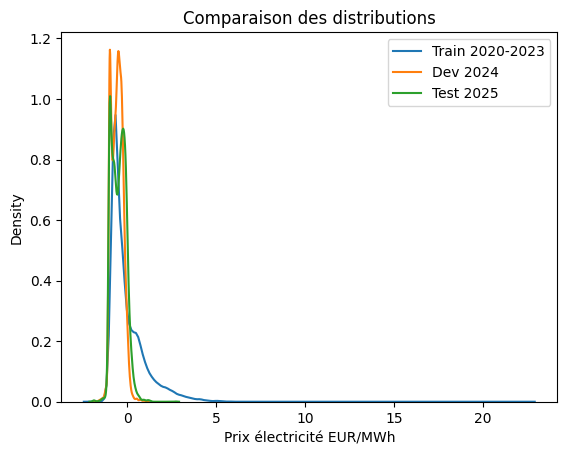

In [23]:
import matplotlib.pyplot as plt

# données brutes pour visualisation
sns.kdeplot(train_df_FR['EUR/MWh'], label='Train 2020-2023')
sns.kdeplot(dev_df_FR['EUR/MWh'], label='Dev 2024')
sns.kdeplot(test_df_FR['EUR/MWh'], label='Test 2025')
plt.xlabel('Prix électricité EUR/MWh')
plt.title('Comparaison des distributions')
plt.legend()
plt.show()


In [24]:
def describe_dataset(df, name):
    return pd.Series({
        'Dataset': name,
        'Mean': df.mean(),
        'Std': df.std(),
        'Min': df.min(),
        'Max': df.max(),
        '25%': df.quantile(0.25),
        'Median': df.median(),
        '75%': df.quantile(0.75)
    })

pd.concat([
    describe_dataset(train_df_FR['EUR/MWh'], 'Train'),
    describe_dataset(dev_df_FR['EUR/MWh'], 'Dev'),
    describe_dataset(test_df_FR['EUR/MWh'], 'Test')
], axis=1)

,0,1,2
Dataset,Train,Dev,Test
Mean,0.0,-0.553195,-0.467035
Std,1.0,0.31672,0.390102
Min,-2.061611,-1.686042,-1.928171
Max,22.551107,1.058723,2.73227
25%,-0.68111,-0.817544,-0.803909
Median,-0.3563,-0.543887,-0.45971
75%,0.401064,-0.324457,-0.173678


In [25]:
from scipy.stats import ks_2samp

ks_train_dev = ks_2samp(train_df_FR['EUR/MWh'], dev_df_FR['EUR/MWh'])
ks_train_test = ks_2samp(train_df_FR['EUR/MWh'], test_df_FR['EUR/MWh'])

print("KS Train vs Dev:", ks_train_dev)
print("KS Train vs Test:", ks_train_test)


KS Train vs Dev: KstestResult(statistic=0.311908197651211, pvalue=0.0, statistic_location=0.02699287171531061, statistic_sign=-1)
KS Train vs Test: KstestResult(statistic=0.25935993555996084, pvalue=0.0, statistic_location=0.13497380793467342, statistic_sign=-1)


In [26]:
ks_dev_test = ks_2samp(dev_df_FR['EUR/MWh'], test_df_FR['EUR/MWh'])
ks_dev_test

KstestResult(statistic=0.1509448110407179, pvalue=1.3785496994487678e-87, statistic_location=-0.23610228529215907, statistic_sign=1)

Epoch 1/50 - Train MAE: 0.4668 - Dev MAE: 0.1811
Epoch 2/50 - Train MAE: 0.3002 - Dev MAE: 0.1719
Epoch 3/50 - Train MAE: 0.2532 - Dev MAE: 0.1725
Epoch 4/50 - Train MAE: 0.2246 - Dev MAE: 0.1667
Epoch 5/50 - Train MAE: 0.2057 - Dev MAE: 0.1630
Epoch 6/50 - Train MAE: 0.1983 - Dev MAE: 0.1734
Epoch 7/50 - Train MAE: 0.1891 - Dev MAE: 0.1724
Epoch 8/50 - Train MAE: 0.1857 - Dev MAE: 0.1633
Epoch 9/50 - Train MAE: 0.1815 - Dev MAE: 0.1842
Epoch 10/50 - Train MAE: 0.1733 - Dev MAE: 0.1535
Epoch 11/50 - Train MAE: 0.1709 - Dev MAE: 0.1617
Epoch 12/50 - Train MAE: 0.1688 - Dev MAE: 0.1605
Epoch 13/50 - Train MAE: 0.1673 - Dev MAE: 0.1612
Epoch 14/50 - Train MAE: 0.1664 - Dev MAE: 0.1646
Epoch 15/50 - Train MAE: 0.1619 - Dev MAE: 0.1734
Epoch 16/50 - Train MAE: 0.1607 - Dev MAE: 0.1766
Epoch 17/50 - Train MAE: 0.1603 - Dev MAE: 0.1817
Epoch 18/50 - Train MAE: 0.1594 - Dev MAE: 0.1715
Epoch 19/50 - Train MAE: 0.1574 - Dev MAE: 0.1710
Epoch 20/50 - Train MAE: 0.1567 - Dev MAE: 0.1766
Epoch 21/

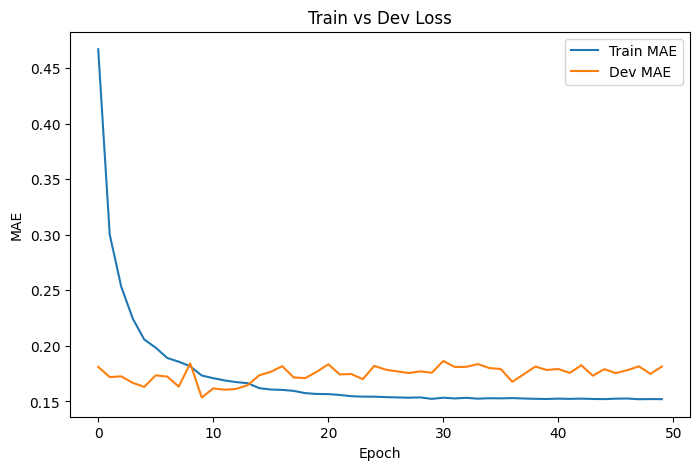

In [27]:
model, train_hist, val_hist = train_conv_lstm(
    X_train, y_train_FR, 
    X_dev, y_dev_FR,
    batch_size=128, epochs=50, lr=0.0007,
    dropout=0.12, l1_lambda=3.5e-5
)

plot_loss(train_hist, val_hist, "conv_lstm_loss.jpg")

In [34]:
print(y_test_FR_1d.shape)

(8566, 24)


In [33]:
from torch.utils.data import DataLoader, TensorDataset

# Préparer le DataLoader de test
batch_size = 64  # ou plus petit si tu es toujours à OOM
X_test_t = torch.tensor(X_test, dtype=torch.float32)
test_loader = DataLoader(TensorDataset(X_test_t), batch_size=batch_size)

# Faire les prédictions par batch
y_preds = []
model.eval()
with torch.no_grad():
    for xb in test_loader:
        xb = xb[0].to(device)
        yb_pred = model(xb)
        y_preds.append(yb_pred.cpu())

# Concaténer tous les batchs
y_pred = torch.cat(y_preds, dim=0).numpy()
print(y_pred.shape)
print(y_pred[:5])


(8566, 24)
[[-0.77269363 -0.8082571  -0.79135597 -0.72835237 -0.6396364  -0.53307325
  -0.44142509 -0.3771496  -0.34697607 -0.3595478  -0.40130964 -0.44667694
  -0.4861068  -0.500548   -0.4876228  -0.45149156 -0.40332684 -0.3570126
  -0.3357935  -0.3400998  -0.3926254  -0.4736093  -0.57024693 -0.661901  ]
 [-0.85565174 -0.8414112  -0.773885   -0.667892   -0.56056684 -0.45920762
  -0.39600617 -0.37119058 -0.3764265  -0.41343978 -0.46406737 -0.5018227
  -0.5177011  -0.5020433  -0.4635969  -0.4120192  -0.36855665 -0.3462102
  -0.36106604 -0.4044897  -0.48914206 -0.58727944 -0.6839897  -0.75643075]
 [-0.86408013 -0.7999534  -0.692878   -0.56519383 -0.46158913 -0.3863527
  -0.3632697  -0.38037303 -0.41506416 -0.46389776 -0.50600284 -0.52081496
  -0.50435334 -0.4583263  -0.40293676 -0.3528367  -0.33014327 -0.344061
  -0.40154076 -0.48286068 -0.58917093 -0.6881979  -0.7642202  -0.80051005]
 [-0.7950046  -0.693      -0.5702801  -0.45310223 -0.37939373 -0.34765115
  -0.3657548  -0.41473684 -0.4

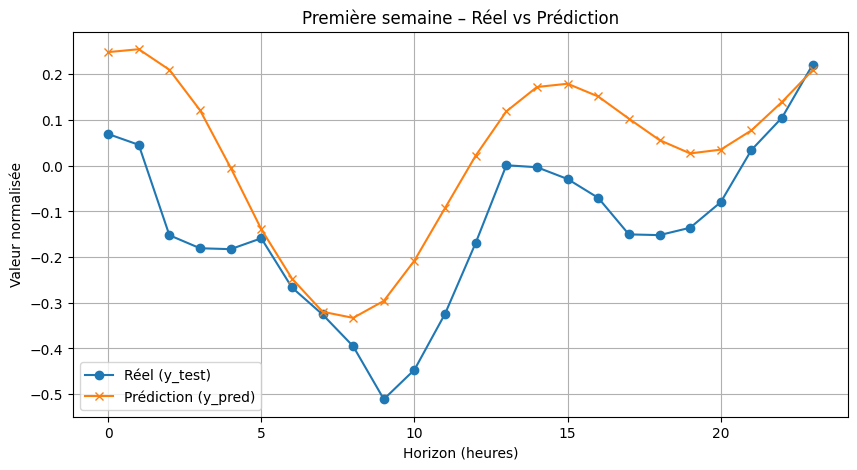

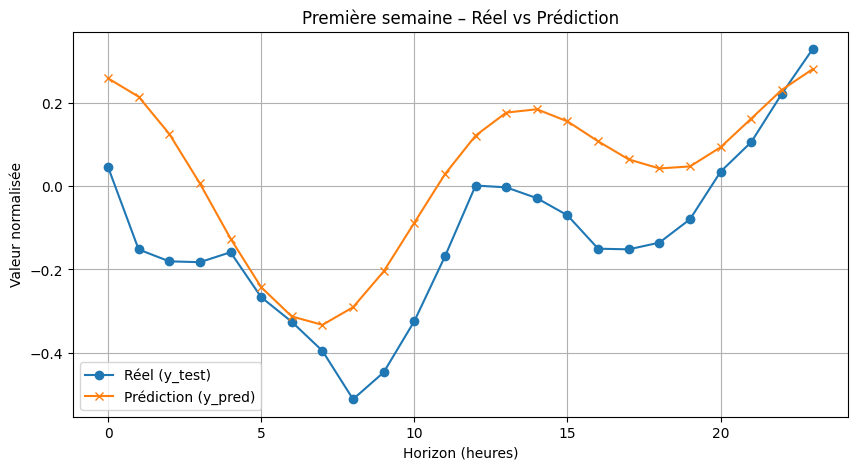

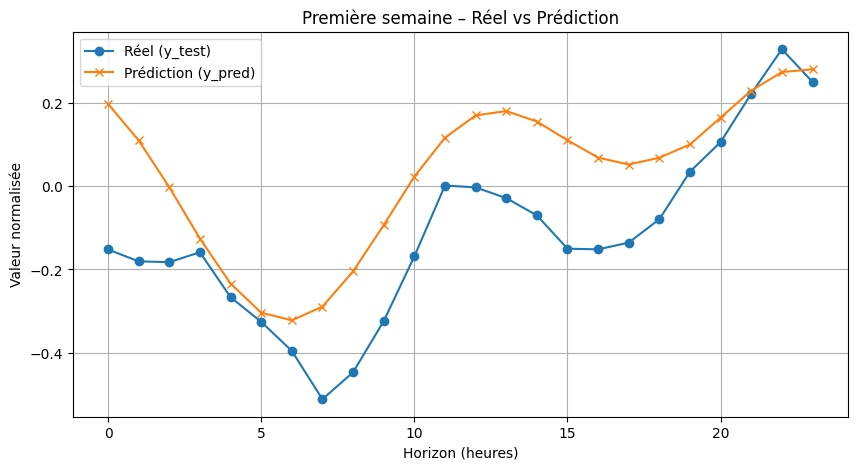

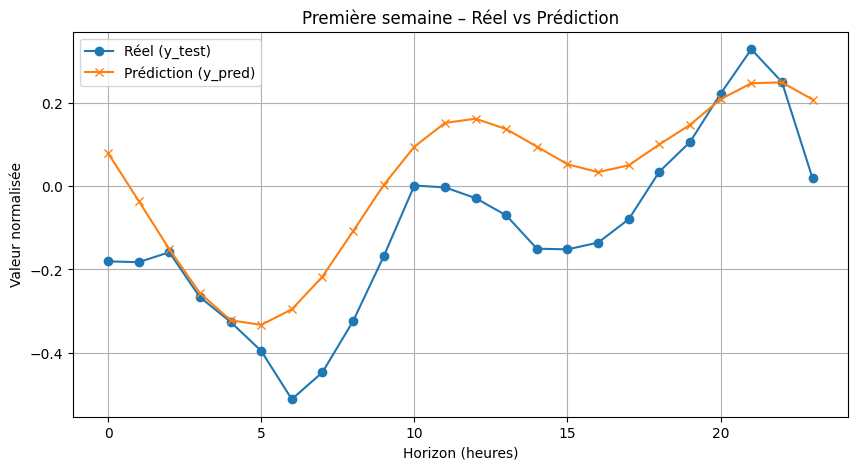

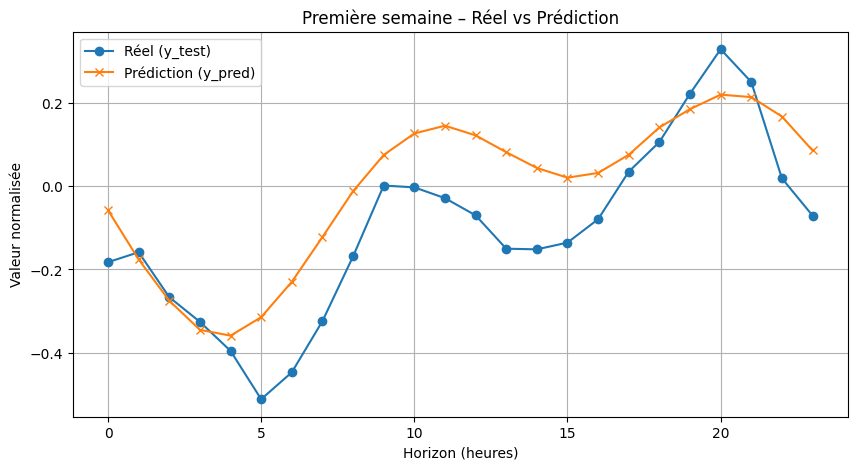

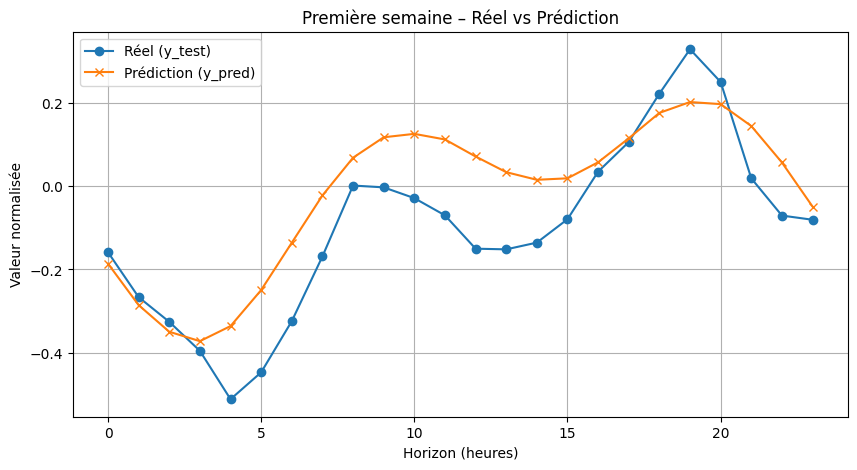

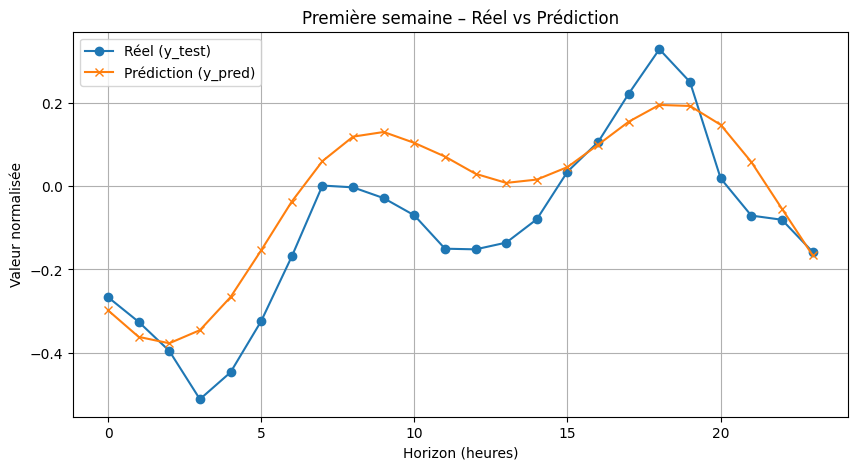

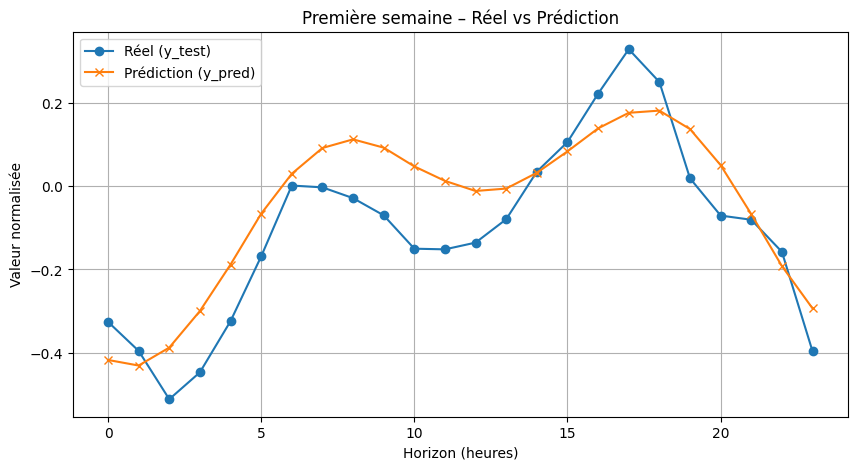

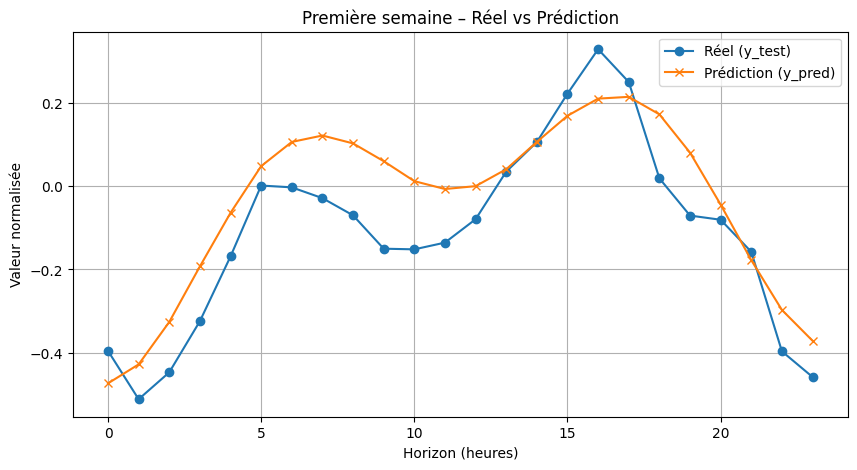

In [53]:
import matplotlib.pyplot as plt

for i in range (1, 10):# Première semaine = 7 premiers horizons
    y_true_week = y_test_FR_1d[1000+i, :24]
    y_pred_week = y_pred[1000+i, :24]
    plt.figure(figsize=(10,5))
    plt.plot(y_true_week, marker='o', label="Réel (y_test)")
    plt.plot(y_pred_week, marker='x', label="Prédiction (y_pred)")
    plt.title("Première semaine – Réel vs Prédiction")
    plt.xlabel("Horizon (heures)")
    plt.ylabel("Valeur normalisée")
    plt.grid(True)
    plt.legend()
    plt.show()

In [56]:
# Flatten réel et prédictions
y_test_flat = y_test_FR_1d.flatten()
y_pred_flat = y_pred.flatten()

# Évaluation
score = error_metric(
    y_true=y_test_flat,
    y_pred=y_pred_flat,
    shift=24*7,     # baseline = valeur 7 jours avant
    L1=True,
    Median=True
)

print(f"Relative MAE (model / naive): {score:.4f}")


Relative MAE (model / naive): nan
